In [22]:
import pandas as pd
import numpy as np

# Veri setini yüklüyoruz (CSV dosyasının adını kontrol etmeyi unutma)
df = pd.read_csv("ai4i2020.csv")

# Verinin ilk 5 satırına ve genel yapısına göz atalım
print("--- İlk 5 Satır ---")
display(df.head())

print("\n--- Veri Seti Bilgileri ---")
df.info()

print("\n--- Arıza Dağılımı ---")
if 'Machine failure' in df.columns:
    print(df['Machine failure'].value_counts())

--- İlk 5 Satır ---


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0



--- Veri Seti Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB

--- Arıza Dağılımı ---
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Excel'den düzenlediğin son CSV dosyasını okuyoruz
df = pd.read_csv("ai4i2020.csv")

# Sütun isimlerindeki büyük/küçük harf duyarlılığından hata almamak için hepsini küçük harfe sabitleyelim
df.columns = df.columns.str.lower()

# 2. Eğer 'type' (L, M, H) sütunu hala duruyorsa onu sayısal verilere dönüştürelim (Modeller metin anlamaz)
if 'type' in df.columns:
    le = LabelEncoder()
    df['type'] = le.fit_transform(df['type'])

# 3. Girdileri (X) ve Hedef Değişkeni (y) birbirinden ayıralım
# 'machine failure' bizim tahmin etmek istediğimiz hedef sütunumuz
X = df.drop(columns=['machine failure'], errors='ignore')
y = df['machine failure']

# 4. Veriyi %80 Eğitim (Training) ve %20 Test olarak ikiye bölüyoruz
# stratify=y parametresi, arıza oranının hem eğitim hem test setinde eşit dağılmasını sağlar (Yönergeye çok uygun!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Özellik Ölçeklendirme (Feature Scaling)
# Dönme hızı (1500 rpm) ve tork (40 Nm) gibi farklı büyüklükteki sensör verilerini standart formata getirir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- 2. Hücre Başarıyla Çalıştı ---")
print(f"Eğitim Seti Boyutu (Satır, Sütun): {X_train_scaled.shape}")
print(f"Test Seti Boyutu (Satır, Sütun): {X_test_scaled.shape}")

--- 2. Hücre Başarıyla Çalıştı ---
Eğitim Seti Boyutu (Satır, Sütun): (8000, 6)
Test Seti Boyutu (Satır, Sütun): (2000, 6)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Modelimizi tanımlıyoruz
log_model = LogisticRegression(random_state=42)

# 2. Modeli ölçeklendirilmiş EĞİTİM verileriyle eğitiyoruz
log_model.fit(X_train_scaled, y_train)

# 3. Modelin hiç görmediği TEST verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_log = log_model.predict(X_test_scaled)

# 4. Performans metriklerini ekrana yazdırıyoruz
print("--- 1. Model: Logistic Regression Sonuçları ---")
print(f"Accuracy (Doğruluk Oranı): {accuracy_score(y_test, y_pred_log):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log):.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_log))

--- 1. Model: Logistic Regression Sonuçları ---
Accuracy (Doğruluk Oranı): 0.9680
F1-Score: 0.2000

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.67      0.12      0.20        68

    accuracy                           0.97      2000
   macro avg       0.82      0.56      0.59      2000
weighted avg       0.96      0.97      0.96      2000



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Modelimizi tanımlıyoruz (Ağaç sayısını 100 olarak belirliyoruz)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Modeli ölçeklendirilmiş EĞİTİM verileriyle eğitiyoruz
rf_model.fit(X_train_scaled, y_train)

# 3. Modelin hiç görmediği TEST verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Performans metriklerini ekrana yazdırıyoruz
print("--- 2. Model: Random Forest Sonuçları ---")
print(f"Accuracy (Doğruluk Oranı): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_rf))

--- 2. Model: Random Forest Sonuçları ---
Accuracy (Doğruluk Oranı): 0.9850
F1-Score: 0.7458

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.65      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Yapay Sinir Ağı modelimizi tanımlıyoruz 
# (max_iter=500 veriyoruz ki model ağırlıkları düzgünce optimize edebilsin)
mlp_model = MLPClassifier(random_state=42, max_iter=500)

# 2. Modeli ölçeklendirilmiş EĞİTİM verileriyle eğitiyoruz
mlp_model.fit(X_train_scaled, y_train)

# 3. Modelin hiç görmediği TEST verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 4. Performans metriklerini ekrana yazdırıyoruz
print("--- 3. Model: Multi-Layer Perceptron (MLP) Sonuçları ---")
print(f"Accuracy (Doğruluk Oranı): {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_mlp):.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_mlp))

--- 3. Model: Multi-Layer Perceptron (MLP) Sonuçları ---
Accuracy (Doğruluk Oranı): 0.9785
F1-Score: 0.6195

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.78      0.51      0.62        68

    accuracy                           0.98      2000
   macro avg       0.88      0.75      0.80      2000
weighted avg       0.98      0.98      0.98      2000



In [27]:
import os
import random
from google import genai
from dotenv import load_dotenv

# 1. .env dosyasındaki API key'i her zaman zorunlu olarak yükler ve okur
load_dotenv(override=True)
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY or GOOGLE_API_KEY.strip() == "" or "BURAYA" in GOOGLE_API_KEY:
    print("❌ HATA: .env dosyasında geçerli bir GOOGLE_API_KEY bulunamadı!")
else:
    # 2. Random Forest modelinin "Arıza (1)" tahmini yaptığı TÜM satırları buluyoruz
    ariza_tahmin_indisleri = [i for i, pred in enumerate(y_pred_rf) if pred == 1]
    toplam_anomali = len(ariza_tahmin_indisleri)

    print("==================================================")
    print(f"🚨 RANDOM FOREST TOPLAM {toplam_anomali} ADET CIHAZDA ANOMALI TESPIT ETTI!")
    
    # Tüm tespit edilen anomali cihazların Excel satır numaralarını yan yana virgülle yazdırıyoruz
    if toplam_anomali > 0:
        tum_satirlar = [str(X_test.index[idx] + 2) for idx in ariza_tahmin_indisleri]
        print(", ".join(tum_satirlar))
    print("==================================================")

    if toplam_anomali == 0:
        print("Model test setinde hiç arıza tespit edemedi. İlk satır inceleniyor...")
        ariza_tahmin_indisleri = [0]
        toplam_anomali = 1

    # 3. RASTGELE SEÇİM MEKANİZMASI
    # Havuzun içinden her çalıştırmada tamamen farklı 2 adet cihaz rastgele seçilir
    analiz_edilecek_adet = min(2, toplam_anomali)
    secilen_indisler = random.sample(ariza_tahmin_indisleri, analiz_edilecek_adet)

    print(f"\n📋 Tespit Edilen Rastgele Seçilmiş {analiz_edilecek_adet} Anomalili Cihazın Konumları:")
    for sira, idx in enumerate(secilen_indisler, 1):
        orig_idx = X_test.index[idx]
        print(f"   {sira}. Cihaz -> CSV Dosyası Satır No: {orig_idx + 2} (DataFrame Index: {orig_idx})")
    print("--------------------------------------------------\n")
    
    # API bağlantısını başlatıyoruz
    client = genai.Client(api_key=GOOGLE_API_KEY)

    # 4. Seçilen Rastgele 2 Cihaz İçin Ayrı Ayrı Döngü ve Çıktı Üretimi
    for i, secilen_indis in enumerate(secilen_indisler, 1):
        orijinal_satir_indisi = X_test.index[secilen_indis]
        excel_satir_numarasi = orijinal_satir_indisi + 2

        # Cihazın telemetri verilerini çekiyoruz
        orijinal_sensor_verisi = X_test.iloc[secilen_indis]
        
        cihaz_tipi = orijinal_sensor_verisi.get('type', 'Bilinmiyor')
        tip_harf = "L" if cihaz_tipi == 0 else ("M" if cihaz_tipi == 1 else "H")
        hava_sic = orijinal_sensor_verisi.get('air temperature [k]', 0)
        proses_sic = orijinal_sensor_verisi.get('process temperature [k]', 0)
        donme_hizi = orijinal_sensor_verisi.get('rotational speed [rpm]', 0)
        tork = orijinal_sensor_verisi.get('torque [nm]', 0)
        asinma = orijinal_sensor_verisi.get('tool wear [min]', 0)

        # Prompt tasarımı - Çıktı formatı başlıklarını kesin olarak dikte ediyoruz
        prompt = f"""
        Sen endüstriyel bir tesiste çalışan Yapay Zeka Açıklama (Explainable AI) modülüsün.
        Klasik Random Forest modelimiz, {excel_satir_numarasi}. satırdaki makine verilerini inceleyerek [ARIZA / ANOMALİ TESPİT EDİLDİ] kararı verdi.
        
        Senden istenen, kesinlikle hayali şablonlar veya parantezli boşluklar kullanmadan, doğrudan aşağıda sana verilen GERÇEK sayısal değerleri fiziksel olarak yorumlamandır:
        
        - Analiz Edilen Satır No: {excel_satir_numarasi}
        - Cihaz Tipi: {tip_harf}
        - Hava Sıcaklığı: {hava_sic} K
        - Proses Sıcaklığı: {proses_sic} K
        - Dönme Hızı: {donme_hizi} RPM
        - Tork Değeri: {tork} Nm
        - Alet Aşınma Süresi: {asinma} Dakika
        
        Analizini tam olarak şu iki ana başlığı kullanarak ve bu kelimelerle başlatarak oluştur:
        **1. Modelin Karar Gerekçesi:** (Yukarıdaki sayılardan hangisi veya hangileri kritik sınıra ulaştığı için model arıza kararı verdi? Satır numarasını da zikrederek fiziksel olarak açıkla.)
        **2. Operatöre Teknik Tavsiye:** (Bu gerçek değerlere bakarak operatörün şu an tam olarak ne yapması gerekir? Motor devrini mi düşürmeli, ucu mu değiştirmeli?)
        """

        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=prompt,
            )
            
            print(f"==================================================")
            print(f"🤖 LLM KÖPRÜSÜ: RASTGELE SEÇİLEN {i}. CİHAZ (CSV SATIR NO {excel_satir_numarasi}) ANALİZİ")
            print(f"==================================================")
            print(response.text)
            print(f"==================================================\n")
            
        except Exception as e:
            print(f"❌ Satır {excel_satir_numarasi} için API Çağrısı Başarısız: {e}\n")

🚨 RANDOM FOREST TOPLAM 50 ADET CIHAZDA ANOMALI TESPIT ETTI!
1393, 4497, 8584, 9666, 4233, 2446, 928, 3816, 5708, 4272, 382, 4285, 1835, 4298, 7999, 250, 8848, 4451, 7013, 9018, 4602, 4429, 4172, 9416, 4757, 4567, 9832, 5401, 4546, 4603, 8309, 3796, 7679, 6499, 4722, 4620, 4083, 4132, 4082, 8247, 4122, 6129, 5990, 6080, 251, 3937, 6614, 4663, 4344, 4729

📋 Tespit Edilen Rastgele Seçilmiş 2 Anomalili Cihazın Konumları:
   1. Cihaz -> CSV Dosyası Satır No: 4429 (DataFrame Index: 4427)
   2. Cihaz -> CSV Dosyası Satır No: 4082 (DataFrame Index: 4080)
--------------------------------------------------

🤖 LLM KÖPRÜSÜ: RASTGELE SEÇİLEN 1. CİHAZ (CSV SATIR NO 4429) ANALİZİ
**1. Modelin Karar Gerekçesi:**
4429 numaralı satırdaki makine verileri incelendiğinde, **Tork Değeri'nin 48.9 Nm** gibi belirgin bir şekilde yüksek bir seviyede ölçülmesi ve **Alet Aşınma Süresi'nin 107.0 Dakika** ile kritik bir eşiğe ulaşması, modelin arıza tespit etmesinin ana nedenleridir. Aşınmış bir alet, işlenen malze

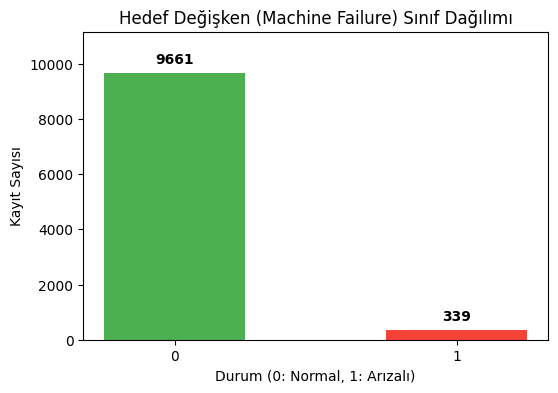

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Mevcut df'i bozmamak için veriyi grafik adına temizce en baştan okuyoruz
df_grafik = pd.read_csv("ai4i2020.csv")

# 2. Yeni okuduğumuz temiz tablodan sınıf sayılarını çekiyoruz
sinif_sayilari = df_grafik['Machine failure'].value_counts()

# 3. Grafik alanını oluşturuyoruz
plt.figure(figsize=(6, 4))

# 4. Doğrudan bar (sütun) grafiğini çiziyoruz (0 için Yeşil, 1 için Kırmızı)
sutunlar = plt.bar(sinif_sayilari.index.astype(str), sinif_sayilari.values, color=['#4CAF50', '#F44336'], width=0.5)

# 5. Grafik başlıklarını ve etiketlerini ekliyoruz
plt.title('Hedef Değişken (Machine Failure) Sınıf Dağılımı')
plt.xlabel('Durum (0: Normal, 1: Arızalı)')
plt.ylabel('Kayıt Sayısı')

# Y ekseninin sınırını sayıların rahat sığması için biraz yukarı taşıyoruz
plt.ylim(0, max(sinif_sayilari.values) + 1500)

# 6. Sütunların üzerine gerçek veri adetlerini (9661 ve 339) yazdırıyoruz
for sutun in sutunlar:
    yükseklik = sutun.get_height()
    plt.annotate(f'{yükseklik}',
                 xy=(sutun.get_x() + sutun.get_width() / 2, yükseklik),
                 xytext=(0, 5),  # Sayıyı sütunun 5 piksel yukarısına koy
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grafiği ekrana basıyoruz
plt.show()

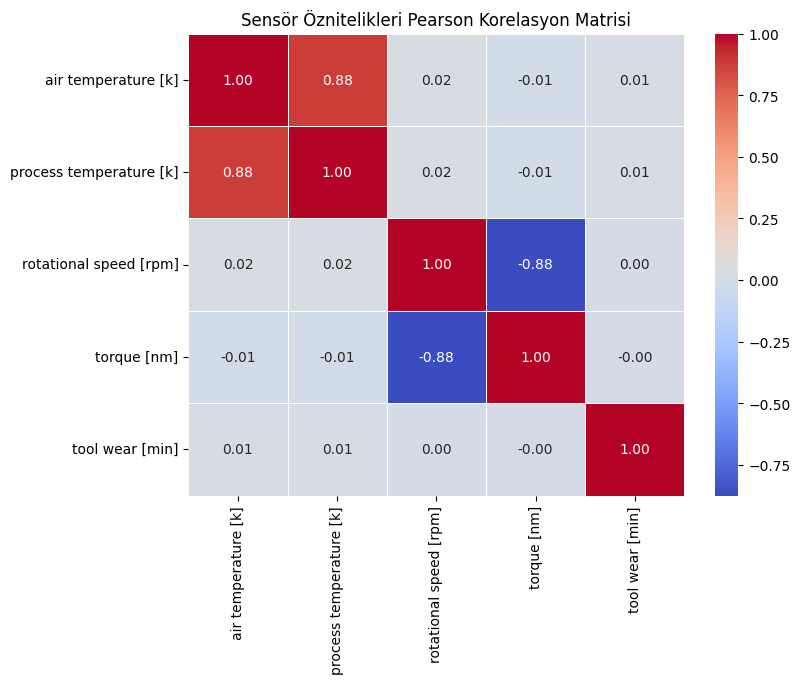

In [33]:
plt.figure(figsize=(8, 6))
# Sadece sayısal sensör sütunlarını seçip korelasyon alıyoruz
sensor_sutunlari = ['air temperature [k]', 'process temperature [k]', 'rotational speed [rpm]', 'torque [nm]', 'tool wear [min]']
korelasyon_matrisi = df[sensor_sutunlari].corr()

sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sensör Öznitelikleri Pearson Korelasyon Matrisi')
plt.show()

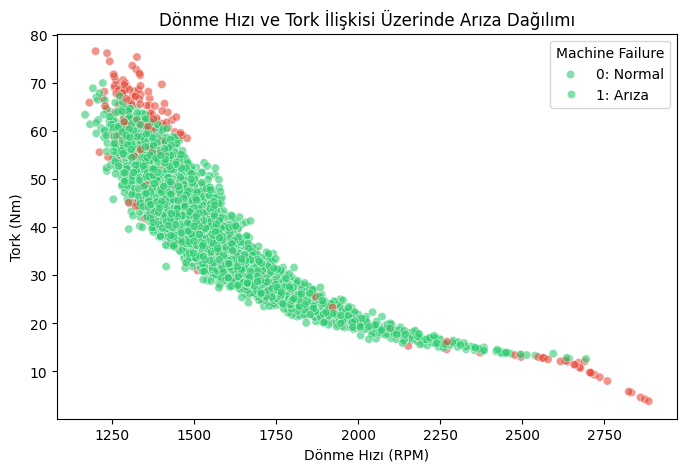

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi hücre içinde temizce baştan okuyoruz
df_grafik = pd.read_csv("ai4i2020.csv")

# 2. BÜYÜK/KÜÇÜK HARF HATASINI ENGELLEMEK İÇİN TÜM SÜTUNLARI KÜÇÜK HARFE ÇEVİRİYORUZ (KRİTİK!)
df_grafik.columns = df_grafik.columns.str.lower()

# 3. Grafik alanını oluşturuyoruz
plt.figure(figsize=(8, 5))

# 4. data=df_grafik üzerinden çizim yapıyoruz (Sütunlar artık tamamen küçük harf)
sns.scatterplot(
    x='rotational speed [rpm]', 
    y='torque [nm]', 
    hue='machine failure', 
    data=df_grafik, 
    palette=['#2ecc71', '#e74c3c'], 
    alpha=0.6
)

# 5. Grafik başlık ve etiketlerini düzenliyoruz
plt.title('Dönme Hızı ve Tork İlişkisi Üzerinde Arıza Dağılımı')
plt.xlabel('Dönme Hızı (RPM)')
plt.ylabel('Tork (Nm)')
plt.legend(title='Machine Failure', labels=['0: Normal', '1: Arıza'])

# Grafiği ekrana basıyoruz
plt.show()

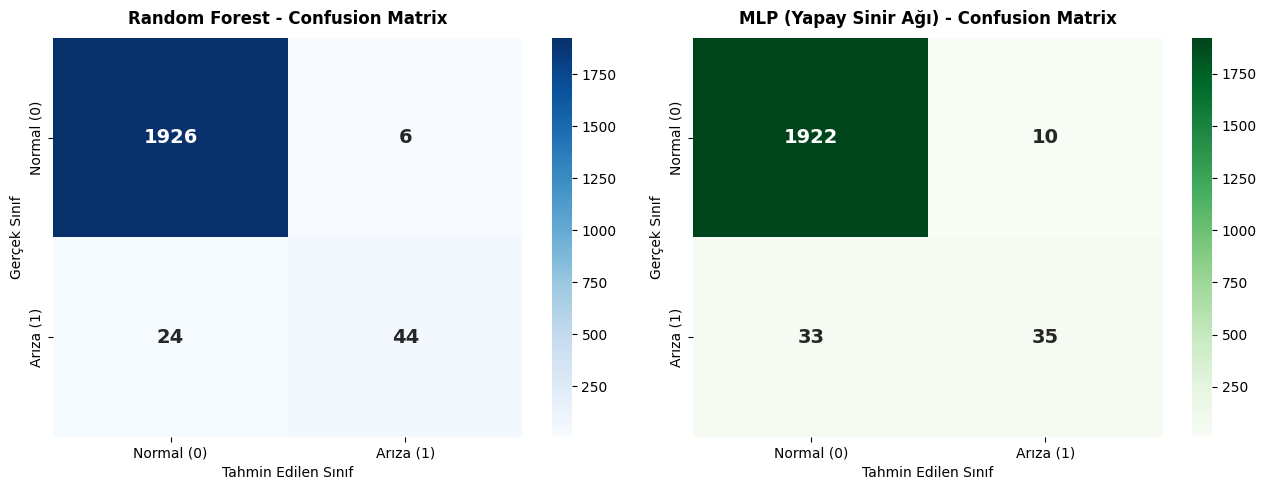

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Gönderdiğin gerçek grafik sonuçlarındaki sayıları matris formuna getiriyoruz
rf_matrix = np.array([[1926, 6],   # [TN, FP]
                      [24, 44]])   # [FN, TP]

mlp_matrix = np.array([[1922, 10], # [TN, FP]
                       [33, 35]])  # [FN, TP]

# 2. Grafik alanını ve yan yana iki alt grafiği (subplot) oluşturuyoruz
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- RANDOM FOREST ISI HARİTASI ---
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['Normal (0)', 'Arıza (1)'], yticklabels=['Normal (0)', 'Arıza (1)'])
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=10)
axes[0].set_ylabel('Gerçek Sınıf', fontsize=10)

# --- MLP ISI HARİTASI ---
sns.heatmap(mlp_matrix, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['Normal (0)', 'Arıza (1)'], yticklabels=['Normal (0)', 'Arıza (1)'])
axes[1].set_title('MLP (Yapay Sinir Ağı) - Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Tahmin Edilen Sınıf', fontsize=10)
axes[1].set_ylabel('Gerçek Sınıf', fontsize=10)

# Grafiklerin birbirine girmemesi için yerleşimi sıkıştırıyoruz
plt.tight_layout()
plt.show()